In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
temperature = np.random.uniform(0, 40, 100)  # Temperature in Celsius
humidity = np.random.uniform(20, 90, 100)  # Humidity percentage
ethylene_gas = np.random.uniform(0, 10, 100)  # Ethylene gas concentration

# Generate labels based on conditions (higher temp, humidity, and ethylene favor spoilage)
labels = np.where(
    (temperature > 25) & (humidity > 60) & (ethylene_gas > 5),
    'Will Spoil',
    'Will not Spoil'
)

# Create DataFrame
df = pd.DataFrame({
    'Temperature': temperature,
    'Humidity': humidity,
    'Ethylene Gas': ethylene_gas,
    'Label': labels
})

# Display the first few rows
df.head()

,Temperature,Humidity,Ethylene Gas,Label
0,14.981605,22.200043,6.420316,Will not Spoil
1,38.028572,64.548729,0.841400,Will not Spoil
2,29.279758,42.004919,1.616287,Will not Spoil
3,23.946339,55.599948,8.985542,Will not Spoil
4,6.240746,83.529653,6.064291,Will not Spoil


In [2]:
# Replace labels with numerical values
df['Label'] = df['Label'].replace({'Will Spoil': 1, 'Will not Spoil': 0})

<ipython-input-2-c1087700380a>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Label'] = df['Label'].replace({'Will Spoil': 1, 'Will not Spoil': 0})


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn import metrics
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, f1_score
# data ingestion

data_path=df

In [ ]:
#df = pd.read_csv(data_path)

In [5]:
df.head(3)

,Temperature,Humidity,Ethylene Gas,Label
0,14.981605,22.200043,6.420316,0
1,38.028572,64.548729,0.841400,0
2,29.279758,42.004919,1.616287,0


In [6]:
df.describe()

,Temperature,Humidity,Ethylene Gas,Label
count,100.000000,100.000000,100.000000,100.000000
mean,18.807230,54.848221,5.176013,0.060000
std,11.899576,20.517788,2.934262,0.238683
min,0.220885,20.486649,0.050616,0.000000
25%,7.728030,36.940317,2.768799,0.000000
50%,18.565698,55.393740,5.625549,0.000000
75%,29.208125,73.632852,7.523669,0.000000
max,39.475477,88.995532,9.900539,1.000000


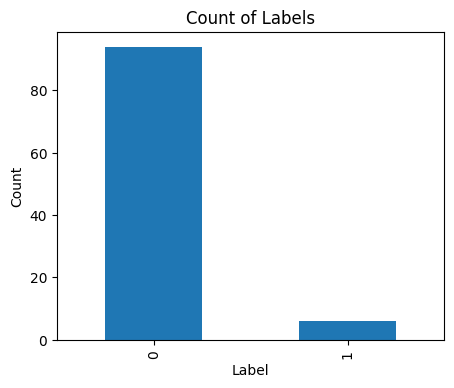

In [7]:
# See distribution of target class
df['Label'].value_counts().plot.bar(figsize=(5,4), xlabel='Label', ylabel='Count', title='Count of Labels')
plt.show()

In [8]:
df.isna().sum()

,0
Temperature,0
Humidity,0
Ethylene Gas,0
Label,0


Number of samples that will spoil = 6 (6.000%)
Number of samples that will not spoil = 94 (94.000%)



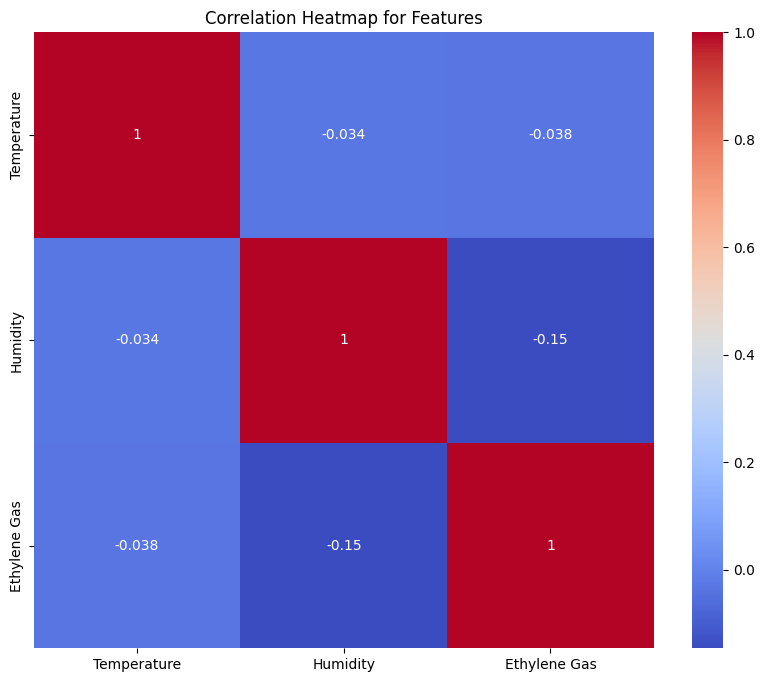

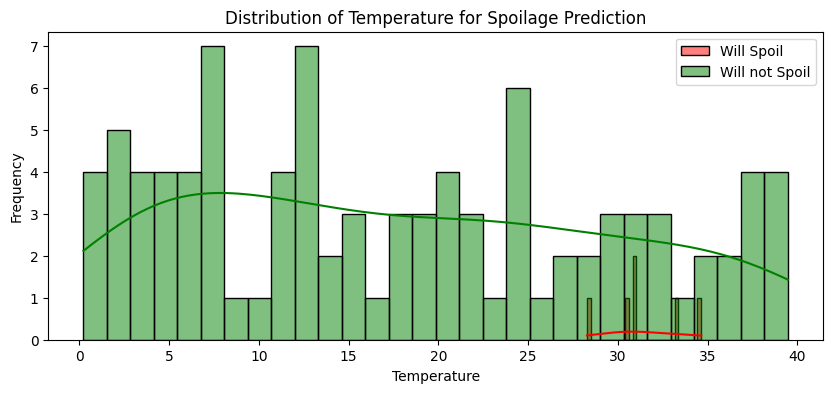

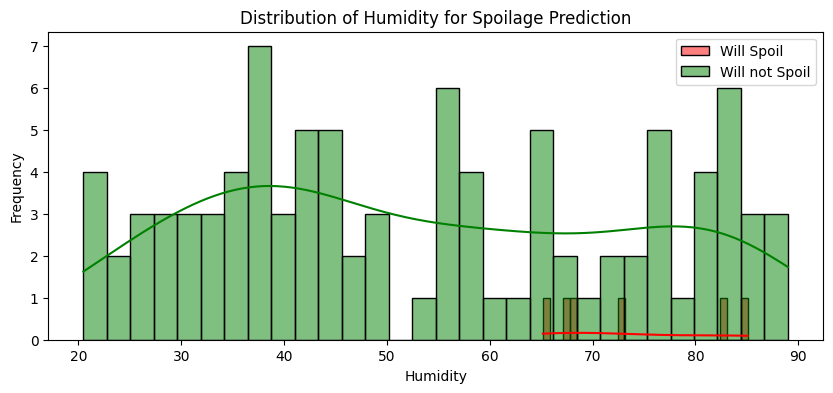

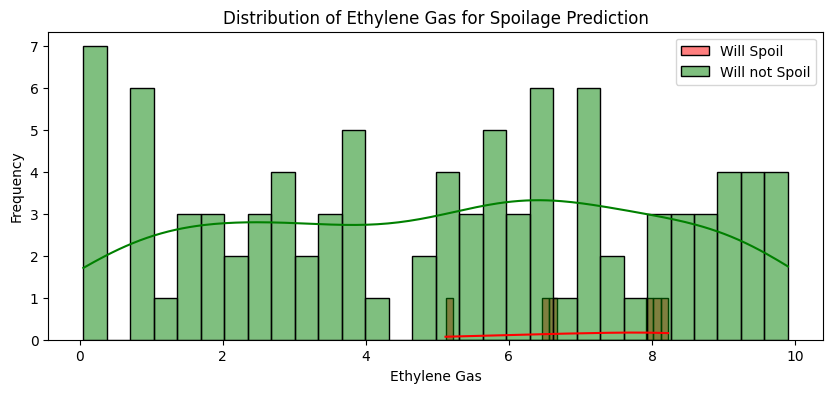

Descriptive statistics for Temperature (samples that will spoil):
count     6.000000
mean     31.398509
std       2.254539
min      28.274294
25%      30.536255
50%      30.870302
75%      32.695727
max      34.647046
Name: Temperature, dtype: float64 

Descriptive statistics for Humidity (samples that will spoil):
count     6.000000
mean     73.658987
std       8.459689
min      65.162095
25%      67.663539
50%      70.627111
75%      80.494093
max      85.078836
Name: Humidity, dtype: float64 

Descriptive statistics for Ethylene Gas (samples that will spoil):
count    6.000000
mean     7.095104
std      1.227530
min      5.113424
25%      6.548464
50%      7.308985
75%      8.065947
max      8.226006
Name: Ethylene Gas, dtype: float64 



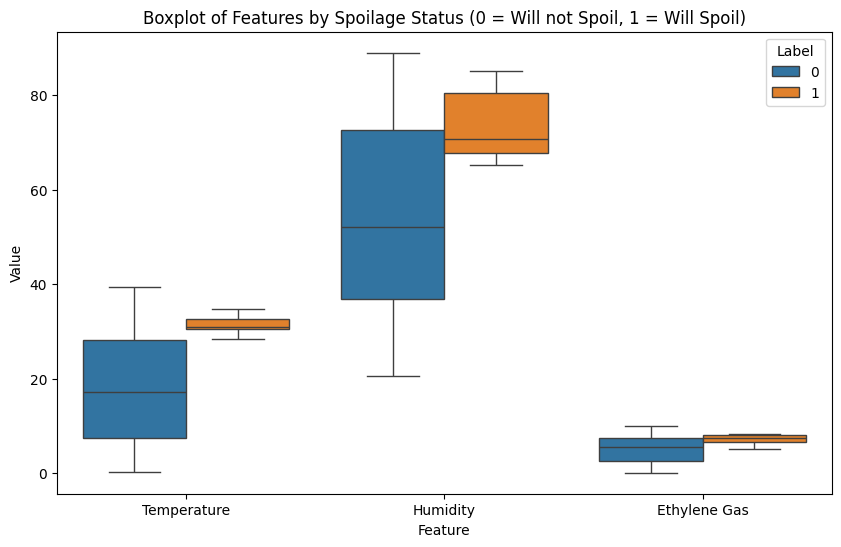

In [9]:
def analyze_spoilage_data(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Separate samples based on spoilage status
    spoiled = df[df['Label'] == 1]
    not_spoiled = df[df['Label'] == 0]

    # Calculate percentages
    total = len(df)
    percent_spoiled = (len(spoiled) / total) * 100
    percent_not_spoiled = (len(not_spoiled) / total) * 100

    print(f'Number of samples that will spoil = {len(spoiled)} ({percent_spoiled:.3f}%)')
    print(f'Number of samples that will not spoil = {len(not_spoiled)} ({percent_not_spoiled:.3f}%)\n')

    # Create a heatmap of correlations for the numeric features
    corr = df[['Temperature', 'Humidity', 'Ethylene Gas']].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap for Features')
    plt.show()

    # List of features to analyze
    features = ['Temperature', 'Humidity', 'Ethylene Gas']

    # Plot overlaid histograms for each feature
    for feature in features:
        plt.figure(figsize=(10, 4))
        sns.histplot(data=spoiled, x=feature, bins=30, kde=True, color='red', label='Will Spoil', alpha=0.5)
        sns.histplot(data=not_spoiled, x=feature, bins=30, kde=True, color='green', label='Will not Spoil', alpha=0.5)
        plt.title(f"Distribution of {feature} for Spoilage Prediction")
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

    # Print descriptive statistics for each feature in the spoiled group
    for feature in features:
        print(f"Descriptive statistics for {feature} (samples that will spoil):")
        print(spoiled[feature].describe(), "\n")

    # Create a boxplot comparing the features by spoilage status
    # First, melt the DataFrame for easier plotting with seaborn
    melted_df = pd.melt(df, id_vars='Label', value_vars=features, var_name='Feature', value_name='Value')
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Feature', y='Value', hue='Label', data=melted_df)
    plt.title('Boxplot of Features by Spoilage Status (0 = Will not Spoil, 1 = Will Spoil)')
    plt.show()

# Example usage:
analyze_spoilage_data(df)

Balanced class distribution:
Label
0    94
1    94
Name: count, dtype: int64


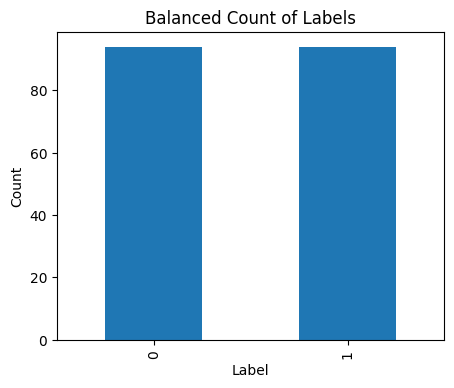

In [10]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Separate the features and target variable
X = df[['Temperature', 'Humidity', 'Ethylene Gas']]
y = df['Label']

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Create a new DataFrame with the balanced data
df = pd.DataFrame(X_res, columns=['Temperature', 'Humidity', 'Ethylene Gas'])
df['Label'] = y_res

# Print the distribution of the balanced classes
print("Balanced class distribution:")
print(df['Label'].value_counts())

# Plot the balanced class distribution
df['Label'].value_counts().plot(
    kind='bar',
    figsize=(5, 4),
    xlabel='Label',
    ylabel='Count',
    title='Balanced Count of Labels'
)
plt.show()

**SVM**

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib
import pickle
import h5py
import numpy as np


# Use the balanced DataFrame from the SMOTE step
X_bal = df[['Temperature', 'Humidity', 'Ethylene Gas']]
y_bal = df['Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM classifier
svm = SVC(random_state=42)

# Train the SVM classifier
svm.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = svm.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Serialize the SVM model using pickle
model_bytes = pickle.dumps(svm)

Accuracy: 0.9649122807017544

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        31
           1       0.93      1.00      0.96        26

    accuracy                           0.96        57
   macro avg       0.96      0.97      0.96        57
weighted avg       0.97      0.96      0.96        57



In [12]:
# Save the SVM model as a pickle file
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

print("SVM model saved as 'svm_model.pkl'.")

SVM model saved as 'svm_model.pkl'.


In [13]:
# Assume X_train is your training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Save the fitted scaler to a file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved as 'scaler.pkl'.")

Scaler saved as 'scaler.pkl'.


In [14]:
import pickle

# Load the SVM model
with open('svm_model.pkl', 'rb') as f:
    svm_loaded= pickle.load(f)

print("SVM model loaded successfully.")

# Load the scaler
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("Scaler loaded successfully.")

SVM model loaded successfully.
Scaler loaded successfully.


In [15]:
import numpy as np

# Define sample inputs as variables (example values)
sample_temperature = 30.0  # in Celsius
sample_humidity = 65.0     # in percentage
sample_ethylene = 6.0      # ethylene gas concentration

# Combine the sample inputs into a NumPy array (note the 2D shape)
sample_input = np.array([[sample_temperature, sample_humidity, sample_ethylene]])

# IMPORTANT: Use the same scaler used during training to transform the new sample
# Assuming 'scaler' is available from the previous code:
sample_input_scaled = scaler.transform(sample_input)

# Make a prediction using the loaded SVM model
sample_prediction = svm_loaded.predict(sample_input_scaled)

# Define mapping from numeric to text labels
label_mapping = {1: 'Will Spoil', 0: 'Will not Spoil'}

# Assume sample_prediction is the numeric output from the model
# For example, sample_prediction might be: array([1])
text_prediction = [label_mapping[pred] for pred in sample_prediction]

print("Textual prediction for the sample input:", text_prediction)

Textual prediction for the sample input: ['Will Spoil']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Random Forest**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle
import h5py
import numpy as np

# Assuming df is your DataFrame with the balanced data from SMOTE
# Use the balanced DataFrame from the SMOTE step
X_bal = df[['Temperature', 'Humidity', 'Ethylene Gas']]
y_bal = df['Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Train the Random Forest classifier
rf.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = rf.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 1.0

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        26

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57



In [17]:
import pickle
from sklearn.preprocessing import StandardScaler

# Save the rf model as a pickle file
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("rf model saved as 'rf_model.pkl'.")

rf model saved as 'rf_model.pkl'.


In [18]:
import pickle

# Load the rf model
with open('rf_model.pkl', 'rb') as f:
     rf_loaded = pickle.load(f)

print("rf model loaded successfully.")

rf model loaded successfully.


In [19]:
# ---------------------------
# Define sample inputs as variables (example values)
sample_temperature = 30.0  # in Celsius
sample_humidity = 65.0     # in percentage
sample_ethylene = 6.0      # ethylene gas concentration

# Combine the sample inputs into a NumPy array (2D shape)
sample_input = np.array([[sample_temperature, sample_humidity, sample_ethylene]])

# IMPORTANT: Use the same scaler used during training to transform the new sample
sample_input_scaled = scaler.transform(sample_input)

# Make a prediction using the loaded Random Forest model
sample_prediction = rf_loaded.predict(sample_input_scaled)

# Define mapping from numeric to text labels
label_mapping = {1: 'Will Spoil', 0: 'Will not Spoil'}

# Convert numeric prediction to text
text_prediction = [label_mapping[pred] for pred in sample_prediction]

print("Textual prediction for the sample input:", text_prediction)

Textual prediction for the sample input: ['Will Spoil']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**RNN**

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Assume 'df' is your balanced DataFrame from the SMOTE step
X_bal = df[['Temperature', 'Humidity', 'Ethylene Gas']]
y_bal = df['Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For RNNs we need a 3D input: (samples, timesteps, features)
# Here, we treat each sample as a sequence with 1 timestep.
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [21]:
# Build the RNN model with an LSTM layer
rnn_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set an early stopping callback to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = rnn_model.fit(X_train_scaled, y_train,
                        validation_split=0.2,
                        epochs=50,
                        batch_size=16,
                        callbacks=[early_stop],
                        verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6660 - loss: 0.6883 - val_accuracy: 0.8148 - val_loss: 0.6794
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8545 - loss: 0.6737 - val_accuracy: 0.8889 - val_loss: 0.6662
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9116 - loss: 0.6548 - val_accuracy: 0.8889 - val_loss: 0.6525
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8903 - loss: 0.6406 - val_accuracy: 0.9630 - val_loss: 0.6394
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9129 - loss: 0.6255 - val_accuracy: 0.9630 - val_loss: 0.6259
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9286 - loss: 0.6117 - val_accuracy: 0.9630 - val_loss: 0.6126
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9107 - loss: 0.6029 - val_accuracy: 0.9630 - val_loss: 0.5993
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9236 - loss: 0.5755 - val_accuracy: 0.9630 - val_loss: 0.5855

In [22]:
# Evaluate the model on the test set
loss, accuracy = rnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print("RNN Test Accuracy:", accuracy)

# Generate predictions (probabilities) and convert them to binary predictions
y_pred_prob = rnn_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Print the classification report
print("\nRNN Classification Report:")
print(classification_report(y_test, y_pred))

RNN Test Accuracy: 0.9298245906829834
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step

RNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        31
           1       0.87      1.00      0.93        26

    accuracy                           0.93        57
   macro avg       0.93      0.94      0.93        57
weighted avg       0.94      0.93      0.93        57



In [23]:
# Save the RNN model in HDF5 (.h5) format
rnn_model.save('rnn_model.h5')
print("RNN model saved in 'rnn_model.h5'.")

RNN model saved in 'rnn_model.h5'.


In [24]:
# ---------------------------
# Load the model from the .h5 file
rnn_loaded = load_model('rnn_model.h5')

In [25]:
# Define sample inputs as variables (example values)
sample_temperature = 30.0  # in Celsius
sample_humidity = 65.0     # in percentage
sample_ethylene = 6.0      # ethylene gas concentration

# Combine the sample inputs into a NumPy array (2D shape)
sample_input = np.array([[sample_temperature, sample_humidity, sample_ethylene]])

# Scale the sample input using the same scaler
sample_input_scaled = scaler.transform(sample_input)
# Reshape to 3D (samples, timesteps, features)
sample_input_scaled = sample_input_scaled.reshape((sample_input_scaled.shape[0], 1, sample_input_scaled.shape[1]))

# Make a prediction using the loaded RNN model
sample_pred_prob = rnn_loaded.predict(sample_input_scaled)
sample_pred = (sample_pred_prob > 0.5).astype(int).reshape(-1)

# Define mapping from numeric to text labels
label_mapping = {1: 'Will Spoil', 0: 'Will not Spoil'}

# Convert numeric prediction to text
text_prediction = [label_mapping[pred] for pred in sample_pred]

print("Textual prediction for the sample input:", text_prediction)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Textual prediction for the sample input: ['Will Spoil']
